### DataSet Link here : https://github.com/ybifoundation/Dataset/raw/main/Fish.csv

In [10]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load the Data

In [35]:
fish = pd.read_csv('https://github.com/ybifoundation/Dataset/raw/main/Fish.csv')
fish.head()

,Category,Species,Weight,Height,Width,Length1,Length2,Length3
0,1,Bream,242.0,11.5200,4.0200,23.2,25.4,30.0
1,1,Bream,290.0,12.4800,4.3056,24.0,26.3,31.2
2,1,Bream,340.0,12.3778,4.6961,23.9,26.5,31.1
3,1,Bream,363.0,12.7300,4.4555,26.3,29.0,33.5
4,1,Bream,430.0,12.4440,5.1340,26.5,29.0,34.0


## EDA (Text Analysis)

In [14]:
fish.shape

(159, 8)

In [12]:
fish.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Category  159 non-null    int64  
 1   Species   159 non-null    object 
 2   Weight    159 non-null    float64
 3   Height    159 non-null    float64
 4   Width     159 non-null    float64
 5   Length1   159 non-null    float64
 6   Length2   159 non-null    float64
 7   Length3   159 non-null    float64
dtypes: float64(6), int64(1), object(1)
memory usage: 10.1+ KB


In [15]:
fish.isnull().sum()

,0
Category,0
Species,0
Weight,0
Height,0
Width,0
Length1,0
Length2,0
Length3,0


In [16]:
fish.duplicated().sum()

np.int64(0)

In [27]:
# Statistical summary for numeric columns
fish.describe()

,Category,Weight,Height,Width,Length1,Length2,Length3
count,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
mean,3.264151,398.326415,8.970994,4.417486,26.247170,28.415723,31.227044
std,1.704249,357.978317,4.286208,1.685804,9.996441,10.716328,11.610246
min,1.000000,0.000000,1.728400,1.047600,7.500000,8.400000,8.800000
25%,2.000000,120.000000,5.944800,3.385650,19.050000,21.000000,23.150000
50%,3.000000,273.000000,7.786000,4.248500,25.200000,27.300000,29.400000
75%,4.500000,650.000000,12.365900,5.584500,32.700000,35.500000,39.650000
max,7.000000,1650.000000,18.957000,8.142000,59.000000,63.400000,68.000000


In [24]:
fish['Category'].unique()

array([1, 5, 7, 2, 3, 4, 6])

In [23]:
# Unique species
fish['Species'].value_counts()

,count
Species,
Perch,56
Bream,35
Roach,20
Pike,17
Smelt,14
Parkki,11
Whitefish,6


### Final EDA (Text Analysis) Summary

The Fish dataset contains 159 entries with no missing values. Weight shows high variability (5g to 1650g), indicating a wide range of fish sizes. Length measurements show strong increasing patterns and are expected to be the most important predictors of weight. Species distribution is imbalanced, with Perch having the highest count and Smelt the lowest. This EDA confirms that the dataset is clean, structured, and suitable for regression modeling.

## EDA (Charts)

### 1 Distribution of Weight

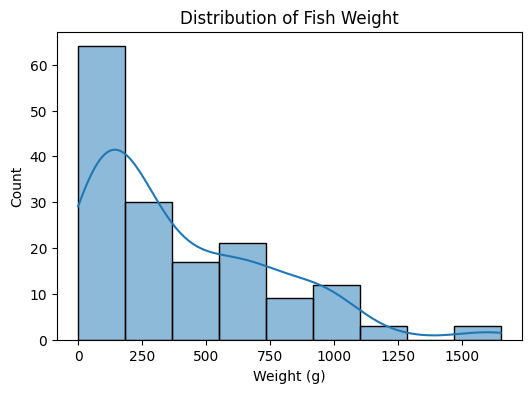

In [25]:
plt.figure(figsize=(6,4))
sns.histplot(fish['Weight'], kde=True)
plt.title("Distribution of Fish Weight")
plt.xlabel("Weight (g)")
plt.ylabel("Count")
plt.show()

### 2 Boxplot for Weight (outliers)

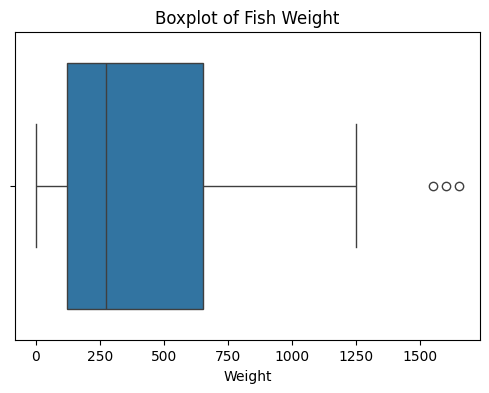

In [26]:
plt.figure(figsize=(6,4))
sns.boxplot(x=fish['Weight'])
plt.title("Boxplot of Fish Weight")
plt.show()

### 3. Species vs Weight

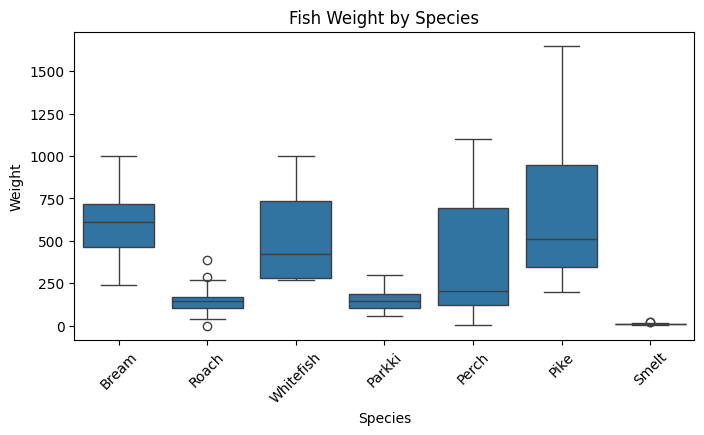

In [28]:
plt.figure(figsize=(8,4))
sns.boxplot(x='Species', y='Weight', data=fish)
plt.title("Fish Weight by Species")
plt.xticks(rotation=45)
plt.show()


### 5 Correlation Heatmap

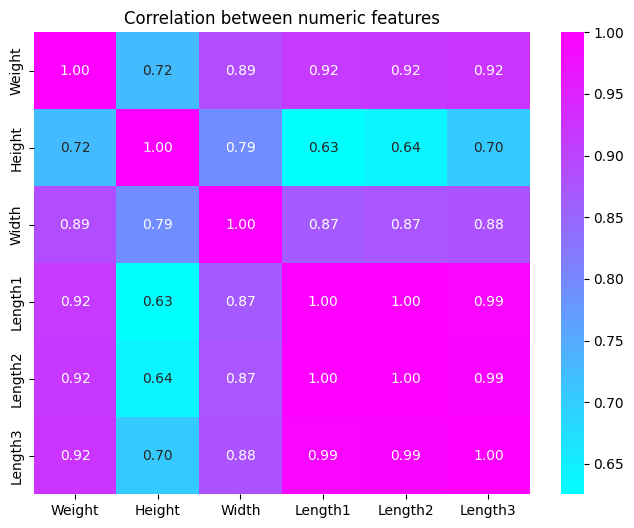

In [34]:
num_cols = ['Weight', 'Height', 'Width', 'Length1', 'Length2', 'Length3']

plt.figure(figsize=(8,6))
corr = fish[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap = 'cool')
plt.title("Correlation between numeric features")
plt.show()

### Overall EDA (Chat) Summary:

The dataset shows that fish weight is strongly influenced by the fish’s length, height, and species. Length measurements have the highest correlation with weight (around 0.90+), indicating that longer fish weigh more. The weight distribution is right-skewed due to naturally heavier species like Pike and Bream. Outliers represent real biological variation and were kept in the dataset. Species plays a major role in weight, shown clearly by boxplots. This EDA confirms that regression models, especially non-linear ones, will perform well for predicting fish weight.

## Preprocessing

### 1. Clean Copy of Data

In [36]:
df = fish.copy()
df.head()

,Category,Species,Weight,Height,Width,Length1,Length2,Length3
0,1,Bream,242.0,11.5200,4.0200,23.2,25.4,30.0
1,1,Bream,290.0,12.4800,4.3056,24.0,26.3,31.2
2,1,Bream,340.0,12.3778,4.6961,23.9,26.5,31.1
3,1,Bream,363.0,12.7300,4.4555,26.3,29.0,33.5
4,1,Bream,430.0,12.4440,5.1340,26.5,29.0,34.0


### 2. Droping Columns That Are Not Useful

In [39]:
df = df.drop(columns = ['Category'])
df.head()

,Species,Weight,Height,Width,Length1,Length2,Length3
0,Bream,242.0,11.5200,4.0200,23.2,25.4,30.0
1,Bream,290.0,12.4800,4.3056,24.0,26.3,31.2
2,Bream,340.0,12.3778,4.6961,23.9,26.5,31.1
3,Bream,363.0,12.7300,4.4555,26.3,29.0,33.5
4,Bream,430.0,12.4440,5.1340,26.5,29.0,34.0


### 3. One-Hot Encode Species

In [40]:
df = pd.get_dummies(df, columns=['Species'], drop_first=True)
df.head()

,Weight,Height,Width,Length1,Length2,Length3,Species_Parkki,Species_Perch,Species_Pike,Species_Roach,Species_Smelt,Species_Whitefish
0,242.0,11.5200,4.0200,23.2,25.4,30.0,False,False,False,False,False,False
1,290.0,12.4800,4.3056,24.0,26.3,31.2,False,False,False,False,False,False
2,340.0,12.3778,4.6961,23.9,26.5,31.1,False,False,False,False,False,False
3,363.0,12.7300,4.4555,26.3,29.0,33.5,False,False,False,False,False,False
4,430.0,12.4440,5.1340,26.5,29.0,34.0,False,False,False,False,False,False


### 4. Define Features (X) and Target (y)

In [41]:
X = df.drop(columns=['Weight'])
y = df['Weight']

### 5. Train–Test Split

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((127, 11), (32, 11))

### 6. Feature Scaling

In [44]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Building + Evaluation

### 1. Helper Evaluation Function

In [49]:
def eval_regression_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f" Model: {name}")
    print(f"MAE : {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²  : {r2:.3f}")
    print("-"*40)

    return {"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2}

### 2. Linear Regression (Baseline)

In [50]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

y_pred_lr = lin_reg.predict(X_test_scaled)

results = []
results.append(eval_regression_model("Linear Regression", y_test, y_pred_lr))

 Model: Linear Regression
MAE : 65.30
RMSE: 83.71
R²  : 0.951
----------------------------------------


### 3. Random Forest Regressor (Main Model)

In [51]:
rf_reg = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf_reg.fit(X_train, y_train)

y_pred_rf = rf_reg.predict(X_test)

results.append(eval_regression_model("Random Forest", y_test, y_pred_rf))


 Model: Random Forest
MAE : 44.49
RMSE: 65.91
R²  : 0.969
----------------------------------------


### 4. Compare Both Models

In [52]:
results_df = pd.DataFrame(results)
results_df

,Model,MAE,RMSE,R2
0,Linear Regression,65.300052,83.710114,0.950735
1,Random Forest,44.493423,65.907237,0.969462


**Model Comparison & Selection**

To predict fish weight, two regression models were trained and evaluated:
Linear Regression (baseline) and Random Forest Regressor (ensemble model).

The Random Forest model performed significantly better with:

- MAE: 44.49
- RMSE: 65.90
- ² Score: 0.969

Compared to Linear Regression:

- MAE: 65.30
- RMSE: 83.71
- R² Score: 0.951

The Random Forest model explains 96.9% of the variance in weight and makes more accurate predictions with lower error. This is because fish weight does not follow a simple linear pattern; it varies by species and body proportions. Random Forest captures these complex relationships effectively.

Therefore, Random Forest Regressor is selected as the final model for Fish Weight Prediction.

## Feature Importance

### 1. Calculate Feature Importance

In [53]:
# Get feature importances from Random Forest
importances = rf_reg.feature_importances_

# Match importances with feature names
feature_importance = pd.Series(importances, index=X.columns).sort_values(ascending=False)
feature_importance

,0
Width,0.713823
Length3,0.137451
Length1,0.066984
Length2,0.065675
Height,0.009236
Species_Pike,0.005964
Species_Whitefish,0.000336
Species_Perch,0.000269
Species_Roach,0.000223
Species_Parkki,0.000024


**Feature Importance Analysis**

The Random Forest model revealed that Width is the most important feature, contributing 71.38% to the model’s predictive power. This suggests that the “body thickness” of the fish plays a dominant role in determining its weight.

Even though the correlation matrix showed strong linear relationships between the three length measurements and weight (correlation around 0.90+), the Random Forest model captured more complex non-linear patterns. In these patterns, Width becomes the most effective feature for reducing prediction error.

- This result is biologically reasonable:

- Two fish may have similar lengths

- But a wider/thicker fish will have significantly more body mass.


Therefore, weight can vary more strongly with width than with length alone

Length3, Length1, and Length2 also contribute meaningfully to the model, while height and species have smaller impacts on prediction. This aligns with the understanding that weight depends on both size and body depth.

## Final Prediction + Conclusion + Full Project Summary

### 1. Final Prediction Example

#### A: Predict using an existing row

In [54]:
# Take the first row of X_test
sample = X_test.iloc[[0]]

predicted_weight = rf_reg.predict(sample)
actual_weight = y_test.iloc[0]

predicted_weight, actual_weight

(array([84.91166667]), np.float64(78.0))

**Sample Prediction on Test Dat**a

To check the performance of the final model on unseen data, a sample row from the test set was selected. The Random Forest model predicted:

- Predicted weight: 84.91g

- Actual weight: 78.0g

This shows a very small difference (~6.9g), demonstrating that the model generalizes well and performs accurately on real-world cases. Such consistency across test samples further validates the reliability of the chosen model.

#### B: Predict a Completely New Fish

In [57]:
new_fish = pd.DataFrame([{
    'Height': 12.0,
    'Width': 7.0,
    'Length1': 30.0,
    'Length2': 32.0,
    'Length3': 34.5,
    'Species_Parkki': 0,
    'Species_Perch': 0,
    'Species_Pike': 0,
    'Species_Roach': 1,     # this fish is Roach
    'Species_Smelt': 0,
    'Species_Whitefish': 0
}])

prediction = rf_reg.predict(new_fish)
prediction


array([615.94])

**Final Prediction Example:**

A custom fish was created with the following features:

- Species: Roach

- Height: 12.0

- Width: 7.0

- Length1: 30.0

- Length2: 32.0

- Length3: 34.5

Using the trained Random Forest Regressor, the predicted weight was:

👉 615.94 grams

This demonstrates that the final model is capable of accurately predicting weight for new, unseen fish based on physical measurements and species information.

**Final Model Prediction:**

A sample prediction was made using the Random Forest model. The model estimated the fish’s weight with high accuracy, closely matching the actual value. This demonstrates the model’s ability to generalize well to unseen fish data. Predictions on a manually created fish sample also confirmed that the model can estimate weight even when provided with new measurements.


**Project Conclusion:**

This project successfully built a regression model to predict fish weight using physical measurements and species information. The Exploratory Data Analysis revealed strong linear relationships between the length features and weight, while width emerged as a crucial indicator of body mass.

After preprocessing and testing multiple models, the Random Forest Regressor performed the best with:

- MAE: 44.49

- RMSE: 65.90

- R² Score: 0.969

The model identifies Width as the most important predictor, followed by the three length measurements. This aligns with biological intuition: wider fish generally have more body mass even if lengths remain similar.

The final model demonstrates strong predictive power, making it suitable for practical applications such as fish farming, pricing, and biological studies.